# Rich Neale's Blocking Diagnostic (ESNB version)
More details on the development process:
[MDTF Planning Document](https://docs.google.com/document/d/1P8HqL8O5304qwR3ik9RmgFDwSWwlkPgOjnp39PIkLfY/edit?usp=sharing)

[ESNB GitHub Repository](https://github.com/jkrasting/esnb/tree/ncar-updates)

In [1]:
# Development mode: constantly refreshes module code
%load_ext autoreload
%autoreload 2


In [ ]:
# Runtime settings (unrelated to the specific diagnostic or the model data)
%%time

# Define a mode (interactive or prod = production (batch))
mode = "interactive"

# Verbosity
verbose = True

# Give your diagnostic a name and a short description
diag_name = "Blocking (Neale) Notebook-based Diagnostic"
diag_desc = "This example demonstrates how to use the notebook template"


In [ ]:
#
# More settings, maybe get rid of some #DRBDBG 
# 

mode = "interactive"
# mode:
#        interactive = running this as a notebook, input is provided through the notebook interface
#        driver      = MDTF called from the command line, input provided through command line arguments (-f file.yaml)

usage = "dev"
# usage:
#         dev  (development): either CESM time series files with no pre-processing done
#                             OR pre-processed files already made, used directly
#         prod (production) : MDTF full functionality. 
#                             Any supported data type is provided through catalogs and translated as necessary
#                             by the MDTF pre-processor.
#       

machine = "casper-env-not-set"
# machine:
#         Uses machine-specfic things such as dask. 
#         This should be determined by the framework
#         And needs implementation for conda envs. 

test = 0 
# test: 
#         test = 1: find and load data, skip analysis/plotting
#         test = 0: run the full analysis and plottings
#



## Framework Code and Diagnostic Setup

In [ ]:
# IMPORT General PACKAGES

import importlib

import sys
import yaml
import json

import os


In [ ]:
# 
# Framework: Setup paths to use MDTF code
#
module_path = os.path.abspath(os.path.join('../../'))  #one above src
print(f"Using MDTF framework version {module_path}")
if module_path not in sys.path:
    sys.path.append(module_path)
from src import util              #, varlist_util, translation, xr_parser, units
from src.util import json_utils

import blocking_utils as block_utils
import blocking_figs as block_figs


Using MDTF framework version /glade/u/home/bundy/mdtf/MDTF_current/MDTF-diagnostics.blocking_notebook


In [ ]:
# The ESNB package has  notebook-specific classes and functions
import esnb
from esnb import NotebookDiagnostic, RequestedVariable, CaseGroup2

os.environ["ESNB_LOG_LEVEL"] = "DEBUG"

In [ ]:
#### POD settings are defined here (interactive mode) or read
#### from the diagnostics/blocking_notebook/settings.jsonc file  

if (mode == "interactive"):
  settings_dict = {
    "settings": {

        # ---------------------------------------------------
        #The pod_env_vars are used in the POD, not required by the MDTF framework
        # ---------------------------------------------------
        "pod_env_vars": {  
            "MDTF_BLOCKING_OBS": True,
            "MDTF_BLOCKING_OBS_USE_CASE_YEARS": False,
            "MDTF_BLOCKING_OBS_ERA_FIRSTYR": 2010,
            "MDTF_BLOCKING_OBS_ERA_LASTYR": 2014,
            "MDTF_BLOCKING_OBS_MERRA_FIRSTYR": 2009,
            "MDTF_BLOCKING_OBS_MERRA_LASTYR": 2011,
            "MDTF_BLOCKING_OBS_CAM5_FIRSTYR": 1979,
            "MDTF_BLOCKING_OBS_CAM5_LASTYR": 2007,
            "MDTF_BLOCKING_CAM3": False,
            "MDTF_BLOCKING_CAM4": False,
            "MDTF_BLOCKING_CAM5": True,
            "MDTF_BLOCKING_READ_DIGESTED": True,
            "MDTF_BLOCKING_WRITE_DIGESTED": False,
            "MDTF_BLOCKING_WRITE_DIGESTED_DIR": "",
            "MDTF_BLOCKING_DEBUG": False
        },
        
        # ---------------------------------------------------
        # The following settings are used by the MDTF framework
        # ---------------------------------------------------
        "runtime_requirements": {
            "python3": None,  # None means use the default python version of the MDTF framework
        },
        "driver": "blocking_main.ipynb",
        "long_name": "Rich Neale's blocking diagnostic",
        "convention": "cesm",
        "description": "Rich Neale's blocking diagnostic", 
    },
    "dimensions": {
        "lat": {
            "standard_name": "latitude",
            "units": "degrees_north",
            "axis": "Y"
        },
        "lon": {
            "standard_name": "longitude",
            "units": "degrees_east",
            "axis": "X"
        },
        "lev": {
            "standard_name": "air_pressure",
            "units": "hPa",
            "positive": "down",
            "axis": "Z"
        },
        "time": {
            "standard_name": "time"
        }
    },
    "varlist": {
        "zg": {
            "path_variable": "MODEL_DATA_PATH",  
            "standard_name": "geopotential_height",
            "units": "m",
            "realm": "atmos",
            "frequency": "day",
            "dimensions": [
                "time",
                "lat",
                "lon"
            ],
            "scalar_coordinates": {
                "lev": 500
            }
        }
    }
}
else:  # batch mode: running from the command line, read in the settings file
    import json

    # Specify the path to the JSONC file
    settings_file_path = "./settings.jsonc"

    try:
        # Open and read the JSONC file using MDTF framework's json_utils
        settings = json_utils.read_json(settings_file_path)
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

# Pretty-print the loaded JSON data
print(json_utils.pretty_print_json(settings_dict))
    



In [ ]:
# Q4JOHN: Can we initialize the NotebookDiagnostic with the settings_dict (above) instead of the file? Note that logic above allows the file to be used, 
# And I think we should ask developers to generate a settings file before submitting. But while developing, it is easier to use the settings_dict directly.

#  Initialize the diagnostic with its name, description, vars, and options
# This is the setttings file from mdtf/diagnostics/$DIAG_NAME/settings.jsonc (Must be full path)
#test diag = NotebookDiagnostic("/glade/u/home/bundy/diag/mdtf/esnb/esnb/src/esnb/data/settings.jsonc")
diag = NotebookDiagnostic("/glade/u/home/bundy/diag/mdtf/MDTF_3_main/MDTF-diagnostics.blocking_notebook/diagnostics/blocking_neale_nb/settings.jsonc")
#print(diag)
from pprint import pprint
pprint(vars(diag))

2025-08-13 14:14:19,406 - INFO - NotebookDiagnostic.py:104 - Initalizing NotebookDiagnostic object from /glade/u/home/bundy/diag/mdtf/MDTF_3_main/MDTF-diagnostics.blocking_notebook/diagnostics/blocking_neale_nb/settings.jsonc
2025-08-13 14:14:19,409 - INFO - NotebookDiagnostic.py:140 - Reading MDTF settings file from: /glade/u/home/bundy/diag/mdtf/MDTF_3_main/MDTF-diagnostics.blocking_notebook/diagnostics/blocking_neale_nb/settings.jsonc


In [ ]:
#This information should be deduced from the mdtf/data/fieldlist_$MODEL.json files
mapping = {
    "zg": "Z500",
}


In [ ]:
# Q4JOHN: Can we initialize CaseGroup2 directly from the dict here, with the option of reading from in input...yml file?

if (mode == "interactive"):
    # If running in interactive mode, input case settings are made here. Otherwise they are read from the args
    # This should contain everything in the input file. Extra key value pairs can be added in a later cell.
    case_info = {
     "case_list": {
            "timeslice_mdtfv3": { #case name
                "convention": "CESM",
                "enddate": "19961231000000",
                "model": "CESM",
                "startdate": "19950101000000"
            }
        },
        "DATA_CATALOG": "/glade/u/home/bundy/diag/mdtf/catalogs/esm_catalog_CESM_timeslice_mdtfv3.20241107.json",
        "OBS_DATA_ROOT": "/glade/work/bundy/mdtf/inputdata/obs_data",
        "WORK_DIR": "/glade/work/bundy/mdtf/outdir/20250429/blocking_nb",
        "OUTPUT_DIR": "/glade/work/bundy/mdtf/outdir/20250429/blocking_nb", #leaving blank will use the WORK_DIR
        "conda_env_root": "/glade/work/bundy/miniconda2/envs.MDTF.20241107/",
        "conda_root": "/glade/work/bundy/miniconda2/",
        "large_file": False,
        "make_multicase_figure_html": False,
        "make_variab_tar": False,
        "micromamba_exe": "",
        "overwrite": True,
####       "pod_list": ["Wheeler_Kiladis"],
        "run_pp": True,
        "save_pp_data": True,
        "save_ps": False,
        "translate_data": True,
        "user_pp_scripts": [""]
    }
else:
    # Receive a dictionary of case information from the framework. 
    # This needs to be passed from the MDTF framework (will be an argument to the command line call)"
    case_input_file =  "../../input_files/input_timeslice_test.yml"
    print("reading default settings from {case_input_file}")

    assert os.path.isfile(case_input_file), f"case environment file not found"
    with open(case_input_file, 'r') as stream:
        try:
            case_info = yaml.safe_load(stream)
        except yaml.YAMLError as exc:
            print(exc)

print(yaml.dump(case_info))



In [7]:
# 
# Set which model experiements (cases) to run the diagnostic on
# This is the input file from mdtf/diagnostics/$DIAG_NAME/input_files
# or can be modified here, for example date_range is a subset of what is available. 
#
groups = [
    CaseGroup2(
        "/glade/u/home/bundy/diag/mdtf/MDTF_3_main/MDTF-diagnostics.blocking_notebook/input_files/input_timeslice_test.yml",
        date_range=("1998-01-01", "2004-12-31"),
        mapping=mapping,
    )
]

2025-08-13 14:14:19,512 - INFO - CaseGroup2.py:308 - Initializing CaseGroup object(s) from source: /glade/u/home/bundy/diag/mdtf/MDTF_3_main/MDTF-diagnostics.blocking_notebook/input_files/input_timeslice_test.yml
2025-08-13 14:14:19,513 - INFO - CaseGroup2.py:311 - Variable mapping dictionary provided; will rename variables if necessary.
2025-08-13 14:14:19,513 - DEBUG - util_case.py:85 - Assuming source is a local file path - /glade/u/home/bundy/diag/mdtf/MDTF_3_main/MDTF-diagnostics.blocking_notebook/input_files/input_timeslice_test.yml
2025-08-13 14:14:19,515 - DEBUG - util_case.py:107 - Source is not a JSON file, assuming MDTF settings file
2025-08-13 14:14:19,516 - INFO - CaseExperiment2.py:75 - Loading MDTF Settings File
2025-08-13 14:14:19,519 - DEBUG - CaseExperiment2.py:91 - Loading intake catalog from path specified in MDTF settings file: /glade/u/home/bundy/diag/mdtf/catalogs/esm_catalog_CESM_timeslice_mdtfv3.20241107.json
2025-08-13 14:14:19,521 - INFO - util_catalog.py:261

In [8]:
#Inspect the one case more carefully
groups[0].cases[0]

Source Type,mdtf_settings
catalog,esm_catalog_CESM_timeslice_mdtfv3.20241107 catalog with 3 dataset(s) from 38 asset(s)
DATA_CATALOG,/glade/u/home/bundy/diag/mdtf/catalogs/esm_catalog_CESM_timeslice_mdtfv3.20241107.json
OBS_DATA_ROOT,/glade/work/bundy/mdtf/inputdata/obs_data
OUTPUT_DIR,
WORK_DIR,/glade/work/bundy/mdtf/outdir/20250403
case_list,"{'timeslice_mdtfv3': {'model': 'CESM', 'convention': 'CESM', 'startdate': '19950101000000', 'enddate': '19961231000000'}}"
conda_env_root,/glade/work/bundy/miniconda2/envs.MDTF.20241107/
conda_root,/glade/work/bundy/miniconda2/
large_file,False
make_multicase_figure_html,False


In [9]:
#This does a lot: including reading the catalog, renaming the variables and finding which files to open
diag.resolve(groups)

2025-08-13 14:14:19,630 - DEBUG - NotebookDiagnostic.py:449 - Case override settings: ESNB_CASE_DATA=None
2025-08-13 14:14:19,631 - DEBUG - NotebookDiagnostic.py:450 - Case override settings: ESNB_CASE_FILE=None
2025-08-13 14:14:19,631 - INFO - CaseGroup2.py:380 - Resolving case: timeslice_mdtfv3
2025-08-13 14:14:19,631 - INFO - CaseGroup2.py:383 - Found n=1 catalogs from individual cases
2025-08-13 14:14:19,632 - INFO - CaseGroup2.py:387 - Renaming dictionary found; about to rename variables
2025-08-13 14:14:19,632 - INFO - CaseGroup2.py:394 - Renamed variable: zg --> Z500
2025-08-13 14:14:19,632 - INFO - CaseGroup2.py:396 - Processing variable `Z500` for case `timeslice_mdtfv3`
2025-08-13 14:14:19,676 - DEBUG - CaseGroup2.py:120 - Searching for: variable `Z500` and found 1 candidates


In [10]:
# Print what files are actually being read (as found through the catalog)
diag.files

['/glade/campaign/cgd/amp/bundy/mdtf/cesm_mdtfv3_timeslice_public/atm/day/cesm_mdtfv3_timeslice.Z500.day.nc']

In [11]:
#Open the model data files
diag.open()

2025-08-13 14:14:19,933 - INFO - NotebookDiagnostic.py:343 - Opening `Z500` datasets for group: timeslice_mdtfv3
2025-08-13 14:14:19,933 - DEBUG - NotebookDiagnostic.py:349 - Checking for cached file: /glade/derecho/scratch/bundy/tmp/gladeuhomebundydiagmdtfMDTF3mainMDTFdiagnosticsblockingnotebookdiagnosticsblockingnealenbsettingsjsonc_2025-08-13_141419_225v8hnc/timeslice_mdtfv3_Z500_1998-01-01_2004-12-31.zarr
2025-08-13 14:14:19,934 - DEBUG - util_xr.py:80 - Found 1 CaseExperiment objects in this group
2025-08-13 14:14:19,934 - DEBUG - util_xr.py:86 - This case has 1 elements: [CaseExperiment2(timeslice_mdtfv3)]
2025-08-13 14:14:19,939 - DEBUG - util_xr.py:13 - Found unix_file files: ['/glade/campaign/cgd/amp/bundy/mdtf/cesm_mdtfv3_timeslice_public/atm/day/cesm_mdtfv3_timeslice.Z500.day.nc']
2025-08-13 14:14:19,940 - INFO - util_xr.py:16 - Opening local files in xarray: ['/glade/campaign/cgd/amp/bundy/mdtf/cesm_mdtfv3_timeslice_public/atm/day/cesm_mdtfv3_timeslice.Z500.day.nc']


ERROR 1: PROJ: proj_create_from_database: Open of /glade/u/apps/opt/conda/envs/npl-2025a/share/proj failed


2025-08-13 14:14:25,551 - INFO - NotebookDiagnostic.py:368 - Subsetting time range ('1998-01-01', '2004-12-31'): timeslice_mdtfv3


In [12]:
# Show what datasets are available
diag.datasets

[<xarray.Dataset> Size: 565MB
 Dimensions:  (lat: 192, lon: 288, time: 2555)
 Coordinates:
   * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
   * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
   * time     (time) object 20kB 1998-01-01 00:00:00 ... 2004-12-31 00:00:00
 Data variables:
     Z500     (time, lat, lon) float32 565MB dask.array<chunksize=(81, 91, 137), meta=np.ndarray>
 Attributes:
     Conventions:       CF-1.0
     source:            CAM
     case:              bhist.e213cosp217.f09_g17.mdtf_v3.1995
     logname:           bundy
     host:              cheyenne5
     initial_file:      bhist.e213cosp217.f09_g17.mdtf_v3.1993.cam.i.1995-01-0...
     topography_file:   /glade/p/cesmdata/cseg/inputdata/atm/cam/topo/fv_0.9x1...
     model_doi_url:     https://doi.org/10.5065/D67H1H0V
     time_period_freq:  day_1]

<i>(The files above are necessary to run the diagnostic.)</i>

In [14]:
diag.variables[0]

RequestedVariable Z500

## Example: Exploring Datasets by Looping Over Variables

In [15]:
# First loop over variables, and then over groups

for variable in diag.variables:
    for group in variable.datasets.keys():
        ds = variable.datasets[group]
        print("\n")
        print(f"Variable={variable}, Group={group}")
        print(ds)



Variable=Z500, Group=timeslice_mdtfv3
<xarray.Dataset> Size: 565MB
Dimensions:  (lat: 192, lon: 288, time: 2555)
Coordinates:
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
  * time     (time) object 20kB 1998-01-01 00:00:00 ... 2004-12-31 00:00:00
Data variables:
    Z500     (time, lat, lon) float32 565MB dask.array<chunksize=(81, 91, 137), meta=np.ndarray>
Attributes:
    Conventions:       CF-1.0
    source:            CAM
    case:              bhist.e213cosp217.f09_g17.mdtf_v3.1995
    logname:           bundy
    host:              cheyenne5
    initial_file:      bhist.e213cosp217.f09_g17.mdtf_v3.1993.cam.i.1995-01-0...
    topography_file:   /glade/p/cesmdata/cseg/inputdata/atm/cam/topo/fv_0.9x1...
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    time_period_freq:  day_1


In [23]:
#See some actual numbers, just checking that the data is there
#print(ds["Z500"].values[:10, :10, :10])  # Print first 10 values for Z500 variable

## Example: Exploring Datasets by Looping over Groups

In [24]:
# First loop over groups, and then over variables

for group in diag.groups:
    for variable in group.datasets.keys():
        ds = group.datasets[variable]
        print("\n")
        print(f"Variable={variable}, Group={group}")
        print(ds)



Variable=Z500, Group=timeslice_mdtfv3
<xarray.Dataset> Size: 565MB
Dimensions:  (lat: 192, lon: 288, time: 2555)
Coordinates:
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
  * time     (time) object 20kB 1998-01-01 00:00:00 ... 2004-12-31 00:00:00
Data variables:
    Z500     (time, lat, lon) float32 565MB dask.array<chunksize=(81, 91, 137), meta=np.ndarray>
Attributes:
    Conventions:       CF-1.0
    source:            CAM
    case:              bhist.e213cosp217.f09_g17.mdtf_v3.1995
    logname:           bundy
    host:              cheyenne5
    initial_file:      bhist.e213cosp217.f09_g17.mdtf_v3.1993.cam.i.1995-01-0...
    topography_file:   /glade/p/cesmdata/cseg/inputdata/atm/cam/topo/fv_0.9x1...
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    time_period_freq:  day_1


# Blocking Code Starts
Merging in from blocking_main_pres-esnb.ipynb


In [20]:
# These need a different python environment, so this won't work yet
if (machine ==  "casper"):
    from dask.distributed import Client
    from ncar_jobqueue import NCARCluster

    cluster = NCARCluster(project='P93300642',interface='mgt', job_extra_directives=[])
    cluster
    cluster.scale(jobs=8)
    client = Client(cluster)
    client


# DRBDBG From here down is raw blocking code. need to replace the case_list structure with the diag structure!

In [ ]:
# Overwrite CASE settings if running in dev mode

#DIAG structure
#for group in diag.groups:
#    for variable in group.datasets.keys():
#        ds = group.datasets[variable]

for group in diag.groups: 
    print(f"Group: {group.name}")
    n_cases = len(group.datasets)
    print(f"Found {n_cases=} in group")
    print(f"  Group items {group.cases=}")

    for case in group.cases:
        print(f"Case attributes for {case.name}:")
        #for attr, value in vars(case).items():
        #fails on Nans in realm column
        #    print(f"  {attr}: {value}")
            
        print(f"    name: {case.name}")
        print(f"    Files: {case.files()}")
        print(f"    source: {case.source}")        
        #print(f"    all mdtf_settings: {case.mdtf_settings}")
        
        #Example on how to get something out of the structure
        mdtf_settings = case.mdtf_settings
        
        #All settings case_list = mdtf_settings.get('case_list')
        #print(f"    {case_list=}") 
        
        for case_name, case_details in case_list.items():
            print(f"Model: {case_details.get('model')}")
            print(f"Convention: {case_details.get('convention')}")
            print(f"Start Date: {case_details.get('startdate')}")
            print(f"End Date: {case_details.get('enddate')}")


Group: timeslice_mdtfv3
Found n_cases=1 in group
  Group items group.cases=[CaseExperiment2(timeslice_mdtfv3)]
Case attributes for timeslice_mdtfv3:
    name: timeslice_mdtfv3
    Files: ['/glade/campaign/cgd/amp/bundy/mdtf/cesm_mdtfv3_timeslice_public/atm/day/cesm_mdtfv3_timeslice.Z500.day.nc']
    source: /glade/u/home/bundy/diag/mdtf/MDTF_3_main/MDTF-diagnostics.blocking_notebook/input_files/input_timeslice_test.yml
    case_list={'timeslice_mdtfv3': {'model': 'CESM', 'convention': 'CESM', 'startdate': '19950101000000', 'enddate': '19961231000000'}}
Model: CESM
Convention: CESM
Start Date: 19950101000000
End Date: 19961231000000


In [ ]:
# DRBDBG : Already opened the files above
#cat_def_file = case_info['DATA_CATALOG']
#cat = intake.open_esm_datastore(cat_def_file)  #DRBDBG we are trying to move away from intake ECG tools. What does the framework use?
#print(f"{cat_def_file=}")


In [ ]:
# Add the obs + comparison ensemble info (all called 'obs', treated as digested/provided data for comparison )
#save all obs_names = ['ERA5','MERRA','CESM2'] (note the last is an ensemble of model runs, treated as obs because we are comparing the MDTF case to it.
# given the grouping capability here, we don't necessarily need to make that distinction unless we are reading it in digested.
obs_names = ['ERA5'] 


# Ensemble members per ensemble set
obs_ens_num = [1,1,10]  

# Total number of items is the number of obs/comparison cases + the MDTF cases requested
n_obs = len(obs_names)
n_all = n_obs + n_cases

all_names   = [""]    *n_all
all_ens_num = [1]     *n_all  #All MDTF cases are single (non-ensemble) for now
all_ystart  = ['1979']*n_all  #Defaults work for obs/ensembles, will be modified with the MDTF case settings above
all_yend    = ['2005']*n_all




In [ ]:
var_subset_cat = cat.search(variable_id=var_name, frequency="day")
print({var_subset_cat})


{<esm_catalog_CESM_timeslice_mdtfv3.20241107 catalog with 1 dataset(s) from 1 asset(s)>}


In [ ]:
# Read in data!
var_dict = var_subset_cat.to_dataset_dict(
    progressbar=False,
    aggregate=False,
    xarray_open_kwargs={"decode_times": True, "use_cftime": True}
)

print(f"var_dict: {var_dict}")

var_dict: {'CESM.NCAR.atmos.Z500.time: mean.m.19950101:000000-20141226:000000.geopotential_height.Geopotential Z at 500 mbar pressure surface.day./glade/campaign/cgd/amp/bundy/mdtf/cesm_mdtfv3_timeslice_public/atm/day/cesm_mdtfv3_timeslice.Z500.day.nc': <xarray.Dataset>
Dimensions:    (lat: 192, lon: 288, time: 7300, nbnd: 2)
Coordinates:
  * lat        (lat) float64 -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon        (lon) float64 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
  * time       (time) object 1995-01-01 00:00:00 ... 2014-12-31 00:00:00
Dimensions without coordinates: nbnd
Data variables:
    time_bnds  (time, nbnd) object dask.array<chunksize=(365, 2), meta=np.ndarray>
    Z500       (time, lat, lon) float32 dask.array<chunksize=(84, 91, 137), meta=np.ndarray>
Attributes: (12/23)
    Conventions:                      CF-1.0
    source:                           CAM
    case:                             bhist.e213cosp217.f09_g17.mdtf_v3.1995
    logname:     

In [ ]:
# I don't think this does anything, was in John's code.
# renaming keys in var_dict to that found in case_list
var_keys = list(var_dict) 
print(var_keys)

case_keys = list(case_list)
for i in range(len(var_keys)):
#    print(f"---- {i} ------renaming {var_dict[case_keys[i]]} to var_dict.pop(var_keys[i])")
    var_dict[case_keys[i]] = var_dict.pop(var_keys[i])

#print(var_dict)
#print(case_keys)

['CESM.NCAR.atmos.Z500.time: mean.m.19950101:000000-20141226:000000.geopotential_height.Geopotential Z at 500 mbar pressure surface.day./glade/campaign/cgd/amp/bundy/mdtf/cesm_mdtfv3_timeslice_public/atm/day/cesm_mdtfv3_timeslice.Z500.day.nc']



# MAIN ROUTINES


In [ ]:
### Read in obs/ens data

importlib.reload(block_utils) # Update for any edits to utility routines.

print(f"\n Reading files from table below")
fout_dir = case_info['OUTPUT_DIR']
print(f"\n Writing output to {fout_dir}")

# Grab basic ens+run information and populate a dictionary)
block_meta = block_utils.ens_setup(obs_names,obs_ens_num,all_ystart,all_yend)

print(f"block_meta keys: {block_meta.keys()}")
print(f"block_meta: {block_meta}")



 Reading files from table below

 Writing output to /glade/work/bundy/mdtf/outdir/20250429/blocking_nb
-> find_ens_info ->  L66 Ensemble name:  ERA5
-> find_ens_info ->  Dict before DataFrame: {'ERA5': ['obs', 1, '1979', '2005', ['ERA5'], ['/glade/work/rneale/data/ERA5/VAR_TBD.day.mean.nc']]}
block_meta keys: Index(['Ensemble Type', 'Ensemble Size', 'Start Year', 'End Year', 'Run Name',
       'Run File'],
      dtype='object')
block_meta:      Ensemble Type  Ensemble Size Start Year End Year Run Name  \
ERA5           obs              1       1979     2005   [ERA5]   

                                               Run File  
ERA5  [/glade/work/rneale/data/ERA5/VAR_TBD.day.mean...  


In [ ]:
import pandas as pd

# Add the MDTF cases to the dictionary
# Loop over MDTF cases

for case_name in case_list:
    case_details = case_list[case_name]
    if (0) :
        print(f"Case Name: {case_name}")
        print(f"Model: {case_details['model']}")
        print(f"Convention: {case_details['convention']}")
        print(f"Start Date: {case_details['startdate']}")
        print(f"End Date: {case_details['enddate']}")

    # Add to the dictionary
    new_row = {
        'Ensemble Type': 'mdtf',
        'Ensemble Size': 1,
        'Start Year': case_details['startdate'],
        'End Year': case_details['enddate'],
        'Run Name': case_name,
        'Run File': var_dict[case_name]
        }
    new_row_df = pd.DataFrame([new_row], index=[case_name])
    #print(new_row_df)

    block_meta = pd.concat([block_meta, new_row_df])
    

print(block_meta)




                 Ensemble Type  Ensemble Size      Start Year        End Year  \
ERA5                       obs              1            1979            2005   
timeslice_mdtfv3          mdtf              1  19950101000000  19961231000000   

                          Run Name  \
ERA5                        [ERA5]   
timeslice_mdtfv3  timeslice_mdtfv3   

                                                           Run File  
ERA5              [/glade/work/rneale/data/ERA5/VAR_TBD.day.mean...  
timeslice_mdtfv3                                  [time_bnds, Z500]  


In [ ]:
block_season = 'DJF'
block_diag_hem = ['nhem']  
block_diag_set = ['1d']



# Grab daily datasets needed for each 'ensemble'

In [ ]:
cam_var = 'Z500'  #The name of the variable in the digested data, not necessarily the variable in the catalog
ensemble_ds = block_utils.dataset_get(block_meta,cam_var,block_season,block_diag_hem)

-> dataset_get -> Requested season     :  DJF
-> dataset_get ->  == Starting ensemble:  0 ERA5 Type: <class 'list'>
-> dataset_get ->  Opening run_files: ['/glade/work/rneale/data/ERA5/VAR_TBD.day.mean.nc']
-> dataset_get ->  Opening ensemble files ERA5  -  1  ensemble(s)
-> dataset_get -> Requested year range :  1979 - 2005
-> dataset_get ->  Opening file:  0 /glade/work/rneale/data/ERA5/Z500.day.mean.nc ensemble:  ERA5


-> dataset_get ->  == Starting ensemble:  1 timeslice_mdtfv3 Type: <class 'xarray.core.dataset.Dataset'>
-> dataset_get ->  Run file is already an xarray dataset
-> dataset_get ->  Duration: 4.913642644882202



In [ ]:
print(f"ensemble_ds: {ensemble_ds}")

ensemble_ds: {'ERA5': <xarray.Dataset>
Dimensions:    (time: 9862, bnds: 2, lon: 360, lat: 180, name: 1)
Coordinates:
  * time       (time) datetime64[ns] 1979-01-01T11:00:00 ... 2005-12-31T11:00:00
  * lon        (lon) float64 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
  * lat        (lat) float64 -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * name       (name) object 'ERA5'
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] dask.array<chunksize=(365, 2), meta=np.ndarray>
    Z500       (name, time, lat, lon) float32 dask.array<chunksize=(1, 365, 180, 360), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 2.3.0 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Thu Feb 15 15:22:03 2024: ncrename -v z,Z500 Z500.day.mean....
    frequency:    day
    CDO:          Climate Data Operators version 2.3.0 (https://mpimet.mpg.de...
    NCO:          netCDF Operators version 5.1.9 (Homepage = 

#  Calculate/Read/Write blocking frequency: 1D

In [ ]:
#print(ensemble_ds)
ens_names = list(block_meta.index)
print(f"Ensemble names: {ens_names}")

#i = 1
#ens_name = ens_names[i]
#print(f"Changing name of ensemble  {ens_name=}")
#ensemble_ds[ens_name].coords["name"] = ens_name


for i in range(len(ens_names)):
    ens_name = ens_names[i]
    print(f"++++ Ensemble {i}: {ens_name}")
    print(f"      {ensemble_ds[ens_name]}")


#one_ds = 
#print(f"one_ds: {one_ds}")


Ensemble names: ['ERA5', 'timeslice_mdtfv3']
++++ Ensemble 0: ERA5
      <xarray.Dataset>
Dimensions:    (time: 9862, bnds: 2, lon: 360, lat: 180, name: 1)
Coordinates:
  * time       (time) datetime64[ns] 1979-01-01T11:00:00 ... 2005-12-31T11:00:00
  * lon        (lon) float64 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
  * lat        (lat) float64 -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * name       (name) object 'ERA5'
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] dask.array<chunksize=(365, 2), meta=np.ndarray>
    Z500       (name, time, lat, lon) float32 dask.array<chunksize=(1, 365, 180, 360), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 2.3.0 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Thu Feb 15 15:22:03 2024: ncrename -v z,Z500 Z500.day.mean....
    frequency:    day
    CDO:          Climate Data Operators version 2.3.0 (https://mpimet.mpg.de...
    NCO:  

In [ ]:
# Either calculate and write a file with, or read in the blocking frequency
importlib.reload(block_utils) # Update for any edits to utility routines.

ensemble_block_1d = block_utils.block_z500_freq(block_meta,ensemble_ds,fout_dir,block_season,block_diag = '1D', file_opts = 'x')

-> block_z500_freq ->  Starting freq blocking calculation
--> set_file_name_and_check_existance ->   called with file_opts = x, Checking if file is already written
--> set_file_name_and_check_existance ->  File exists, reading in ...
--> block_file_read_write ->  Reading file  /glade/work/bundy/mdtf/outdir/20250429/blocking_nb/block_1D_ERA5_nens.1_1979-2005_DJF.nc
--> block_file_read_write ->  Done ...
-> block_z500_freq ->  Min/max blocking frequency for ensemble  ERA5  =  2.1748050882232253 , 24.169060320065654
--> set_file_name_and_check_existance ->   called with file_opts = x, Checking if file is already written
--> set_file_name_and_check_existance ->  File exists, reading in ...
--> block_file_read_write ->  Reading file  /glade/work/bundy/mdtf/outdir/20250429/blocking_nb/block_1D_timeslice_mdtfv3_nens.1_19950101000000-19961231000000_DJF.nc
--> block_file_read_write ->  Done ...
-> block_z500_freq ->  Min/max blocking frequency for ensemble  timeslice_mdtfv3  =  2.32876712328767


# Calculate/Read/Write blocking frequency: 2D


In [ ]:
ensemble_block_2d = block_utils.block_z500_freq(block_meta,ensemble_ds,fout_dir,block_season,block_diag = '2D', file_opts = 'x')


-> block_z500_freq ->  Starting freq blocking calculation
--> set_file_name_and_check_existance ->   called with file_opts = x, Checking if file is already written
--> set_file_name_and_check_existance ->  File exists, reading in ...
--> block_file_read_write ->  Reading file  /glade/work/bundy/mdtf/outdir/20250429/blocking_nb/block_2D_ERA5_nens.1_1979-2005_DJF.nc
--> block_file_read_write ->  Done ...
-> block_z500_freq ->  Min/max blocking frequency for ensemble  ERA5  =  0.0 , 28.35453426343865
--> set_file_name_and_check_existance ->   called with file_opts = x, Checking if file is already written
--> set_file_name_and_check_existance ->  File exists, reading in ...
--> block_file_read_write ->  Reading file  /glade/work/bundy/mdtf/outdir/20250429/blocking_nb/block_2D_timeslice_mdtfv3_nens.1_19950101000000-19961231000000_DJF.nc
--> block_file_read_write ->  Done ...
-> block_z500_freq ->  Min/max blocking frequency for ensemble  timeslice_mdtfv3  =  0.0 , 28.21917808219178


-> block_plot_1d ->  Plotting for ensemble ERA5
DRBDBG L74 ens_type='obs'
DRBDBG ens_block_1d[ens_name].dims=('name', 'lon')


/glade/work/bundy/miniconda2/envs.MDTF.20241107/_MDTF_base/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


-> block_plot_1d ->  Plotting for ensemble timeslice_mdtfv3
DRBDBG L74 ens_type='mdtf'
DRBDBG ens_block_1d[ens_name].dims=('lon',)


ValueError: 'name' not found in array dimensions ('lon',)

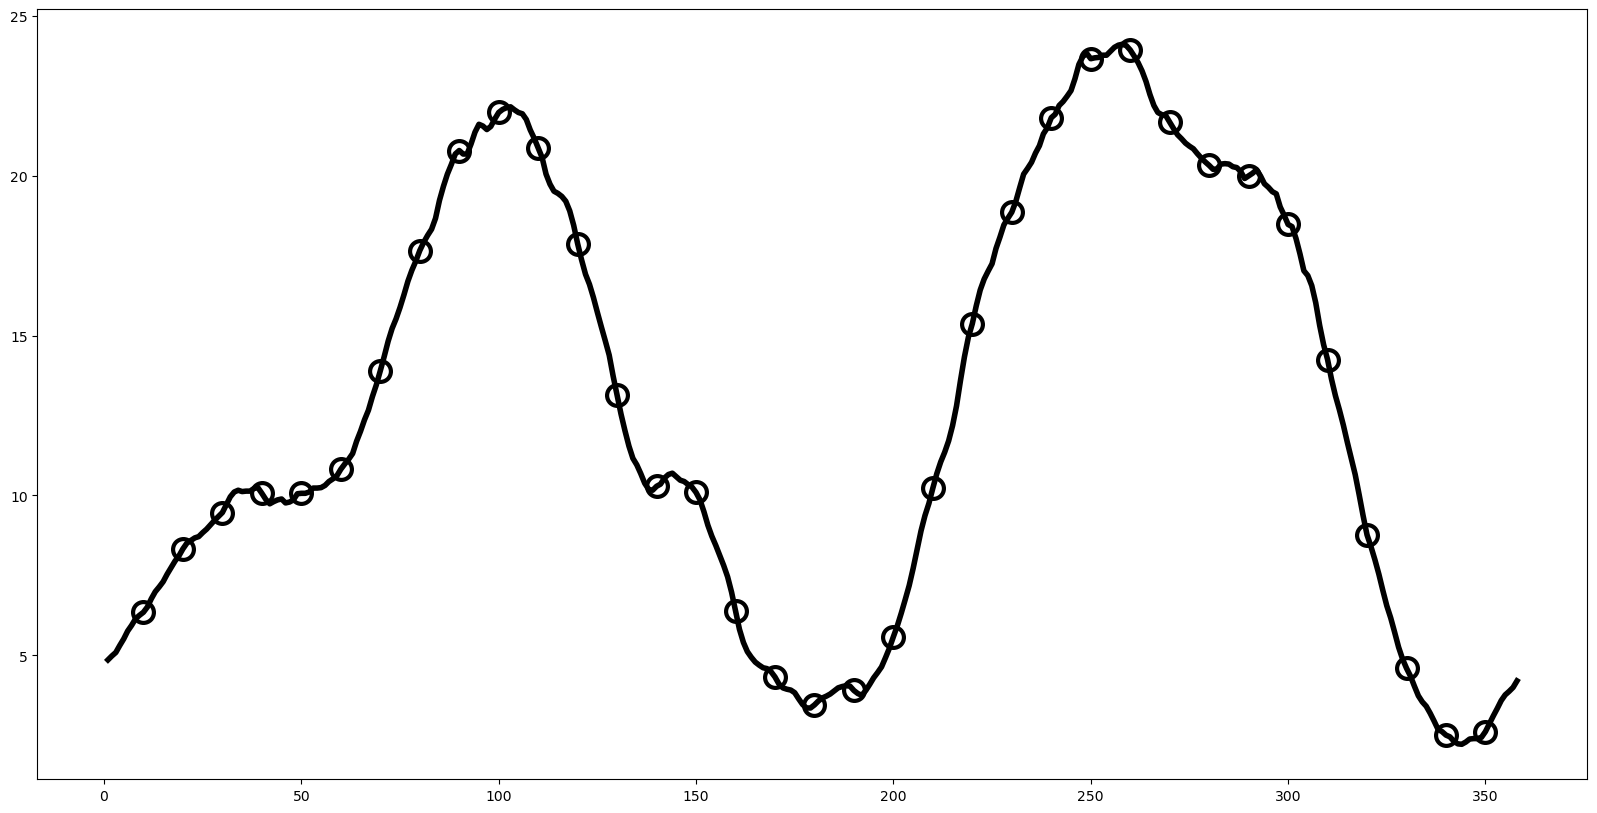

In [ ]:
block_figs.block_plot_1d(block_meta,ensemble_block_1d,block_season,fig_out=True,dir_fig=fout_dir)



# Plot 2D blocking: Ensemble ave, 1 ensemble member, or all ensemble members 


In [ ]:
block_figs.block_plot_2d(block_meta,ensemble_block_2d,block_season,fig_out=True,dir_fig=fout_dir,ens_plot='av')

In [ ]:
block_figs.block_plot_1d(block_meta,ensemble_block_1d,block_season,fig_out=True,dir_fig=fout_dir)